
# Physical Information 
## Proof-of-concept synthetic benchmark notebook linking DNA, brain memory, and digital computation

This notebook builds a **literature-anchored synthetic benchmark** to test the idea that stored information in three very different systems, **DNA**, **brain memory**, and **digital computation**, can be compared within a common thermodynamic framework.

### Key conceptual components
- stored information - physical embodiment - susceptibility to entropy - need for energy


### Important note
This notebook uses **synthetic data**, not experimental measurements. The numerical ranges are anchored to peer-reviewed, journal-indexed literature and are used here to create a transparent **proof of concept**.

### Literature anchors used in the simulation
- **DNA damage burden**: spontaneous DNA damage occurs on the order of about **10<sup>4</sup>–10<sup>5</sup> lesions per cell per day** in mammalian cells, consistent with classic reviews on endogenous DNA damage and repair.
- **Brain glucose use**: resting brain glucose utilization is approximated around **0.25 μmol g⁻¹ min⁻¹** in review-level discussions tied to brain energetics.
- **Thermodynamics of computation**: the **Landauer bound** for minimum bit erasure is \(k_B T \ln 2\).

### Journal-indexed references
1.	Lindahl, T. (1993). Instability and decay of the primary structure of DNA. Nature, 362, 709–715. https://www.nature.com/articles/362709a0  
2.	Barnes, D. E., & Lindahl, T. (2004). Repair and genetic consequences of endogenous DNA base damage in mammalian cells. Annual Review of Genetics, 38, 445–476.
https://www.annualreviews.org/content/journals/10.1146/annurev.genet.38.072902.092448  ￼
3.	Dienel, G. A. (2019). Brain glucose metabolism: Integration of energetics with function. Physiological Reviews, 99, 949–1045.
https://journals.physiology.org/doi/full/10.1152/physrev.00062.2017  ￼
4.	Chattopadhyay, P., Misra, A., Pandit, T., & Paul, G. (2025). Landauer principle and thermodynamics of computation. Reports on Progress in Physics, 88, 086601.
https://iopscience.iop.org/article/10.1088/1361-6633/add6b3

The notebook saves all generated figures and tables under the local output folder.

In [3]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, precision_recall_fscore_support, roc_auc_score
)
from sklearn.linear_model import LinearRegression, Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPRegressor, MLPClassifier
from sklearn.inspection import permutation_importance
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 10

SEED = 42
rng = np.random.default_rng(SEED)

OUTPUT_DIR = Path('information_is_physical_outputs')
FIG_DIR = OUTPUT_DIR / 'figures'
TAB_DIR = OUTPUT_DIR / 'tables'
FIG_DIR.mkdir(parents=True, exist_ok=True)
TAB_DIR.mkdir(parents=True, exist_ok=True)

print('Output directory:', OUTPUT_DIR)


Output directory: information_is_physical_outputs


In [5]:

# Benchmark anchors derived from the literature-inspired framework
k_B = 1.380649e-23  # J K^-1
room_temperature_K = 300.0
landauer_room = k_B * room_temperature_K * np.log(2)

anchors = pd.DataFrame([
    {
        'system': 'DNA',
        'variable': 'spontaneous_lesions_per_cell_per_day',
        'anchor_low': 1e4,
        'anchor_high': 1e5,
        'units': 'lesions/cell/day',
        'rationale': 'Classic endogenous DNA damage estimates'
    },
    {
        'system': 'Brain',
        'variable': 'resting_brain_glucose_utilization',
        'anchor_low': 0.20,
        'anchor_high': 0.30,
        'units': 'μmol/g/min',
        'rationale': 'Resting range centered near review-level value ~0.25'
    },
    {
        'system': 'Bit',
        'variable': 'Landauer_bound_300K',
        'anchor_low': landauer_room,
        'anchor_high': landauer_room,
        'units': 'J/bit',
        'rationale': 'Thermodynamic lower bound at 300 K'
    }
])

display(anchors)
anchors.to_csv(TAB_DIR / 'table_1_literature_anchors.csv', index=False)


,system,variable,anchor_low,anchor_high,units,rationale
0,DNA,spontaneous_lesions_per_cell_per_day,1.000000e+04,1.000000e+05,lesions/cell/day,Classic endogenous DNA damage estimates
1,Brain,resting_brain_glucose_utilization,2.000000e-01,3.000000e-01,μmol/g/min,Resting range centered near review-level value...
2,Bit,Landauer_bound_300K,2.870979e-21,2.870979e-21,J/bit,Thermodynamic lower bound at 300 K


In [7]:
# Synthetic data generation 
N = 800

def bounded_normal(mean, sd, low, high, n=N):
    x = rng.normal(mean, sd, n)
    return np.clip(x, low, high)

# DNA system
dna = pd.DataFrame({
    'lesions_per_day': np.clip(rng.lognormal(mean=np.log(4e4), sigma=0.45, size=N), 1e4, 1e5),
    'oxidative_fraction': bounded_normal(0.35, 0.12, 0.05, 0.75),
    'repair_efficiency': bounded_normal(0.88, 0.07, 0.55, 0.99),
    'chromatin_remodeling_index': bounded_normal(0.62, 0.15, 0.10, 1.00),
    'replication_stress_index': bounded_normal(0.40, 0.18, 0.00, 1.00),
    'antioxidant_capacity_index': bounded_normal(0.58, 0.18, 0.00, 1.00),
    'cell_cycle_pressure_index': bounded_normal(0.45, 0.20, 0.00, 1.00),
})

residual_damage = (
    (dna['lesions_per_day'] / 1e5) * (1 - dna['repair_efficiency']) * (1 + 0.8 * dna['oxidative_fraction'])
    + 0.25 * dna['replication_stress_index']
    + 0.12 * dna['cell_cycle_pressure_index']
    - 0.18 * dna['antioxidant_capacity_index']
    - 0.15 * dna['chromatin_remodeling_index']
)
dna['residual_damage_index'] = np.clip(residual_damage, 0, None)
dna['dna_information_fidelity'] = np.clip(
    1.02
    - 0.85 * dna['residual_damage_index']
    + 0.06 * dna['repair_efficiency']
    + rng.normal(0, 0.025, N),
    0, 1
)
dna['system'] = 'DNA'

# Brain system
brain = pd.DataFrame({
    'brain_glucose_utilization': bounded_normal(0.25, 0.035, 0.16, 0.36),
    'glycogen_support_index': bounded_normal(0.42, 0.16, 0.00, 1.00),
    'protein_synthesis_index': bounded_normal(0.60, 0.17, 0.05, 1.00),
    'synaptic_plasticity_index': bounded_normal(0.63, 0.16, 0.05, 1.00),
    'sleep_consolidation_support': bounded_normal(0.56, 0.18, 0.00, 1.00),
    'oxidative_stress_index': bounded_normal(0.34, 0.15, 0.00, 1.00),
    'network_noise_index': bounded_normal(0.31, 0.15, 0.00, 1.00),
})

brain_signal = (
    1.7 * brain['brain_glucose_utilization']
    + 0.28 * brain['glycogen_support_index']
    + 0.32 * brain['protein_synthesis_index']
    + 0.34 * brain['synaptic_plasticity_index']
    + 0.24 * brain['sleep_consolidation_support']
    - 0.24 * brain['oxidative_stress_index']
    - 0.27 * brain['network_noise_index']
)
brain['memory_retention_score'] = np.clip(
    0.10 + 0.95 * brain_signal + rng.normal(0, 0.03, N),
    0, 1
)
brain['system'] = 'Brain'

# Bit system
bit = pd.DataFrame({
    'temperature_K': bounded_normal(300, 15, 260, 340),
    'barrier_multiple_landauer': bounded_normal(42, 12, 8, 90),
    'hardware_noise_index': bounded_normal(0.24, 0.13, 0.00, 1.00),
    'error_correction_strength': bounded_normal(0.67, 0.16, 0.05, 1.00),
    'practical_reset_energy_multiple': bounded_normal(1e6, 3e5, 1e5, 2e6),
})

bit['landauer_bound_J'] = k_B * bit['temperature_K'] * np.log(2)
bit['practical_reset_energy_J'] = bit['landauer_bound_J'] * bit['practical_reset_energy_multiple']
raw_reliability = (
    0.52
    + 0.22 * np.tanh(bit['barrier_multiple_landauer'] / 25)
    + 0.20 * bit['error_correction_strength']
    - 0.26 * bit['hardware_noise_index']
    - 0.08 * ((bit['temperature_K'] - 300) / 40.0)
)
bit['bit_reliability_score'] = np.clip(raw_reliability + rng.normal(0, 0.025, N), 0, 1)
bit['system'] = 'Bit'

display(dna.head())
display(brain.head())
display(bit.head())


,lesions_per_day,oxidative_fraction,repair_efficiency,chromatin_remodeling_index,replication_stress_index,antioxidant_capacity_index,cell_cycle_pressure_index,residual_damage_index,dna_information_fidelity,system
0,45878.754271,0.248595,0.876155,0.553090,0.296739,0.625577,0.455053,0.001343,1.000000,DNA
1,25050.320110,0.219956,0.959288,0.767029,0.609429,0.741139,0.558535,0.000000,1.000000,DNA
2,56068.967317,0.391353,0.968518,0.662176,0.344884,0.629198,0.447133,0.000000,1.000000,DNA
3,61076.890871,0.395514,0.780477,0.515366,0.598809,0.982990,0.644799,0.149337,0.949354,DNA
4,16625.100294,0.504480,0.858135,0.490109,0.477214,0.837362,0.357613,0.000000,1.000000,DNA


,brain_glucose_utilization,glycogen_support_index,protein_synthesis_index,synaptic_plasticity_index,sleep_consolidation_support,oxidative_stress_index,network_noise_index,memory_retention_score,system
0,0.287931,0.555478,0.656712,0.752740,0.552376,0.104440,0.246694,1.000000,Brain
1,0.216491,0.538231,0.810178,0.760567,0.678239,0.180263,0.245617,1.000000,Brain
2,0.250843,0.506005,0.806691,0.599498,0.710516,0.299491,0.158476,1.000000,Brain
3,0.201645,0.431774,0.523337,0.573800,0.579479,0.123510,0.136932,0.912145,Brain
4,0.243657,0.336100,0.632983,0.811330,0.732050,0.278970,0.319096,1.000000,Brain


,temperature_K,barrier_multiple_landauer,hardware_noise_index,error_correction_strength,practical_reset_energy_multiple,landauer_bound_J,practical_reset_energy_J,bit_reliability_score,system
0,322.172602,32.852812,0.430846,0.500781,6.032534e+05,3.083169e-21,1.859932e-15,0.676338,Bit
1,320.102739,55.209542,0.232223,0.889289,1.416744e+06,3.063361e-21,4.339998e-15,0.782709,Bit
2,289.880898,48.596170,0.082230,0.407433,8.955276e+05,2.774140e-21,2.484319e-15,0.813088,Bit
3,300.142646,53.694439,0.290973,0.932040,9.784528e+05,2.872344e-21,2.810453e-15,0.878044,Bit
4,287.769558,40.897449,0.216905,0.364291,1.085061e+06,2.753934e-21,2.988186e-15,0.732968,Bit


In [9]:

# Benchmark checks 
benchmark_checks = pd.DataFrame([
    {
        'system': 'DNA',
        'metric': 'lesions_per_day_mean',
        'simulated_value': dna['lesions_per_day'].mean(),
        'anchor_low': 1e4,
        'anchor_high': 1e5,
        'within_anchor': 1e4 <= dna['lesions_per_day'].mean() <= 1e5
    },
    {
        'system': 'Brain',
        'metric': 'brain_glucose_utilization_mean',
        'simulated_value': brain['brain_glucose_utilization'].mean(),
        'anchor_low': 0.20,
        'anchor_high': 0.30,
        'within_anchor': 0.20 <= brain['brain_glucose_utilization'].mean() <= 0.30
    },
    {
        'system': 'Bit',
        'metric': 'landauer_bound_mean_300K_order',
        'simulated_value': bit['landauer_bound_J'].mean(),
        'anchor_low': k_B * 280 * np.log(2),
        'anchor_high': k_B * 320 * np.log(2),
        'within_anchor': (k_B * 280 * np.log(2)) <= bit['landauer_bound_J'].mean() <= (k_B * 320 * np.log(2))
    },
])

display(benchmark_checks)
benchmark_checks.to_csv(TAB_DIR / 'table_2_benchmark_checks.csv', index=False)

summary_stats = pd.concat([
    dna.describe().T.assign(system='DNA'),
    brain.describe().T.assign(system='Brain'),
    bit.describe().T.assign(system='Bit')
])
display(summary_stats.head(20))
summary_stats.to_csv(TAB_DIR / 'table_3_summary_statistics.csv')


,system,metric,simulated_value,anchor_low,anchor_high,within_anchor
0,DNA,lesions_per_day_mean,4.324437e+04,1.000000e+04,1.000000e+05,True
1,Brain,brain_glucose_utilization_mean,2.509707e-01,2.000000e-01,3.000000e-01,True
2,Bit,landauer_bound_mean_300K_order,2.866724e-21,2.679580e-21,3.062377e-21,True


,count,mean,std,min,25%,50%,75%,max,system
lesions_per_day,800.0,43244.372996,19078.232609,10536.458459,28991.589509,39845.489618,52795.684443,100000.000000,DNA
oxidative_fraction,800.0,0.345620,0.121180,0.050000,0.266492,0.349194,0.423768,0.731462,DNA
repair_efficiency,800.0,0.874136,0.066760,0.665535,0.829522,0.880674,0.922339,0.990000,DNA
chromatin_remodeling_index,800.0,0.626028,0.149466,0.190772,0.520294,0.621498,0.732876,1.000000,DNA
replication_stress_index,800.0,0.398269,0.176299,0.000000,0.275339,0.393481,0.513984,0.955932,DNA
antioxidant_capacity_index,800.0,0.578903,0.177931,0.014140,0.457820,0.581073,0.686542,1.000000,DNA
cell_cycle_pressure_index,800.0,0.448110,0.192842,0.000000,0.309031,0.450098,0.576362,1.000000,DNA
residual_damage_index,800.0,0.046628,0.057821,0.000000,0.000000,0.022425,0.078837,0.331187,DNA
dna_information_fidelity,800.0,0.988552,0.029588,0.805747,1.000000,1.000000,1.000000,1.000000,DNA
brain_glucose_utilization,800.0,0.250971,0.034583,0.160000,0.229157,0.248564,0.274597,0.360000,Brain


In [ ]:

# Figure 1: Conceptual architecture 
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111)
ax.axis('off')

text = (
    'INFORMATION IN THE REAL WORLD\n\n'
    'stored information → physical embodiment → susceptibility to entropy → need for energy\n\n'
    'DNA: sequence + chromatin state\n'
    'Brain: synaptic + circuit state\n'
    'Bit: binary hardware state\n\n'
    'Destabilizers\n'
    'DNA: lesions, oxidation, replication stress\n'
    'Brain: oxidative stress, network noise, metabolic failure\n'
    'Bit: temperature, hardware noise, leakage\n\n'
    'Maintenance\n'
    'DNA: repair, antioxidant buffering, chromatin remodeling\n'
    'Brain: glucose support, protein synthesis, sleep-linked consolidation\n'
    'Bit: barrier strength, error correction, reset energy\n\n'
    'Thermodynamic anchors\n'
    'S = k_B ln Ω\n'
    'Q_min = k_B T ln 2'
)
ax.text(0.5, 0.5, text, ha='center', va='center', fontsize=12,
        bbox=dict(boxstyle='round,pad=0.8', facecolor='white', edgecolor='black'))
fig.suptitle('Figure 1. Comparative thermodynamic architecture of physically embodied information')
plt.tight_layout()
fig.savefig(FIG_DIR / 'figure_1_conceptual_architecture.png', bbox_inches='tight')
plt.show()


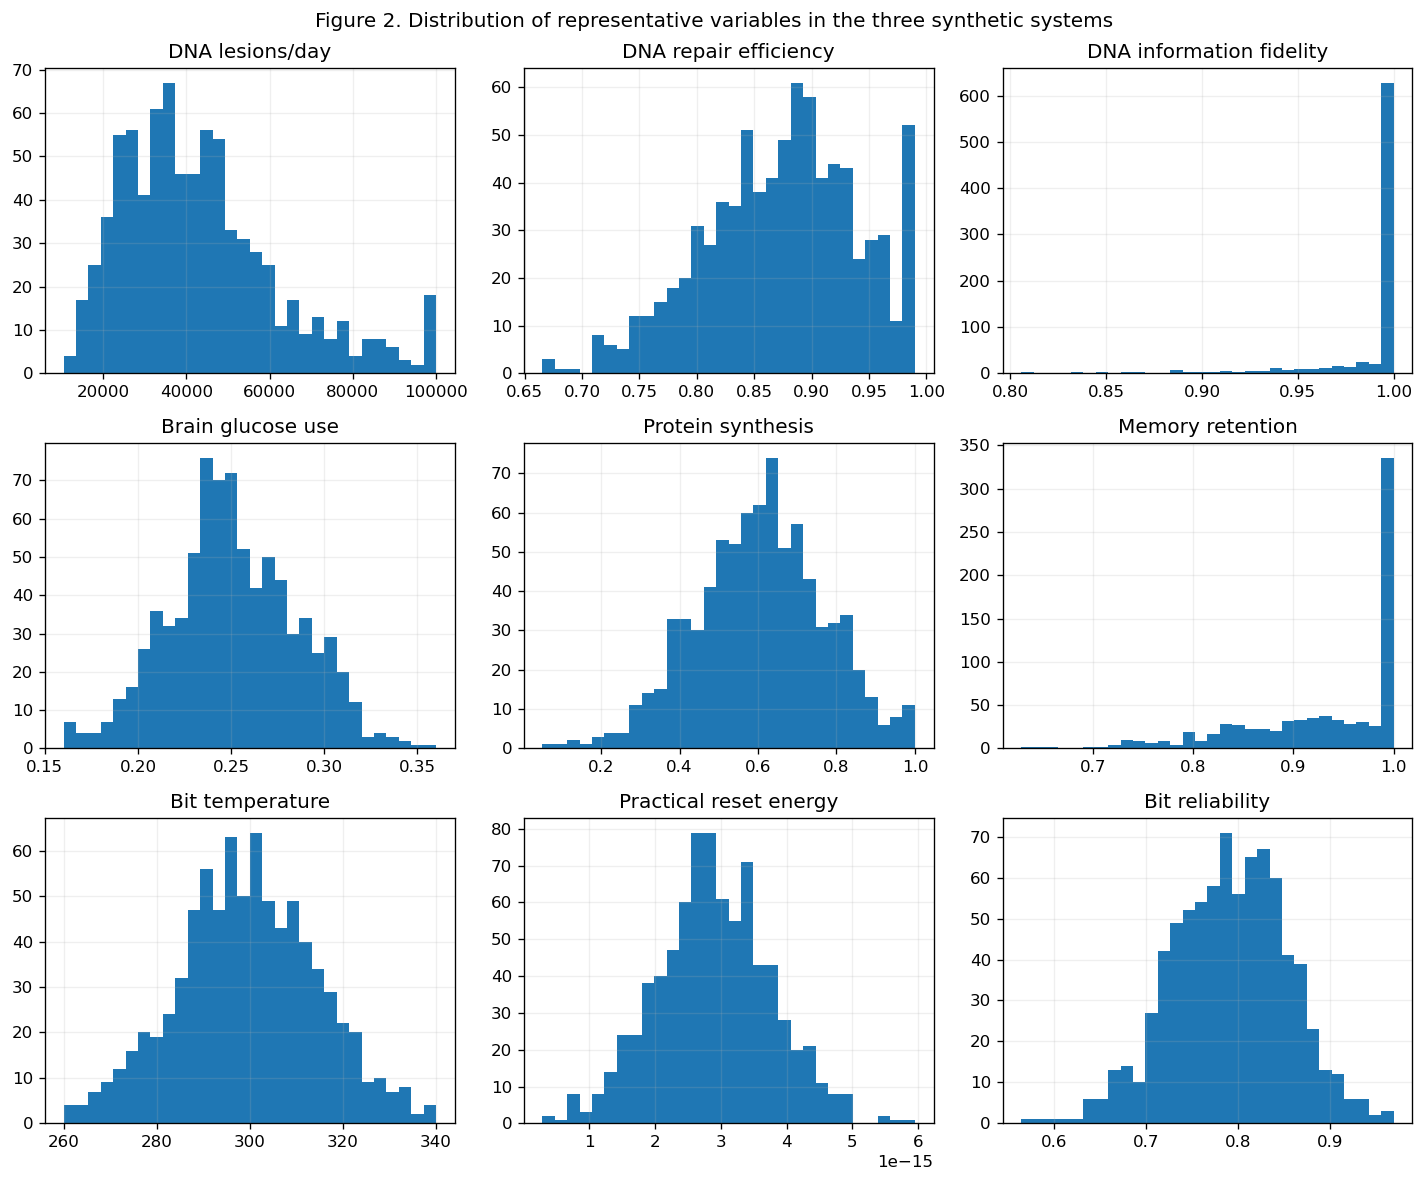

In [11]:

# Figure 2: Distributions 
fig, axes = plt.subplots(3, 3, figsize=(12, 10))

axes[0,0].hist(dna['lesions_per_day'], bins=30)
axes[0,0].set_title('DNA lesions/day')
axes[0,1].hist(dna['repair_efficiency'], bins=30)
axes[0,1].set_title('DNA repair efficiency')
axes[0,2].hist(dna['dna_information_fidelity'], bins=30)
axes[0,2].set_title('DNA information fidelity')

axes[1,0].hist(brain['brain_glucose_utilization'], bins=30)
axes[1,0].set_title('Brain glucose use')
axes[1,1].hist(brain['protein_synthesis_index'], bins=30)
axes[1,1].set_title('Protein synthesis')
axes[1,2].hist(brain['memory_retention_score'], bins=30)
axes[1,2].set_title('Memory retention')

axes[2,0].hist(bit['temperature_K'], bins=30)
axes[2,0].set_title('Bit temperature')
axes[2,1].hist(bit['practical_reset_energy_J'], bins=30)
axes[2,1].set_title('Practical reset energy')
axes[2,2].hist(bit['bit_reliability_score'], bins=30)
axes[2,2].set_title('Bit reliability')

for ax in axes.flat:
    ax.grid(alpha=0.2)

fig.suptitle('Figure 2. Distribution of representative variables in the three synthetic systems')
plt.tight_layout()
fig.savefig(FIG_DIR / 'figure_2_distributions.png', bbox_inches='tight')
plt.show()


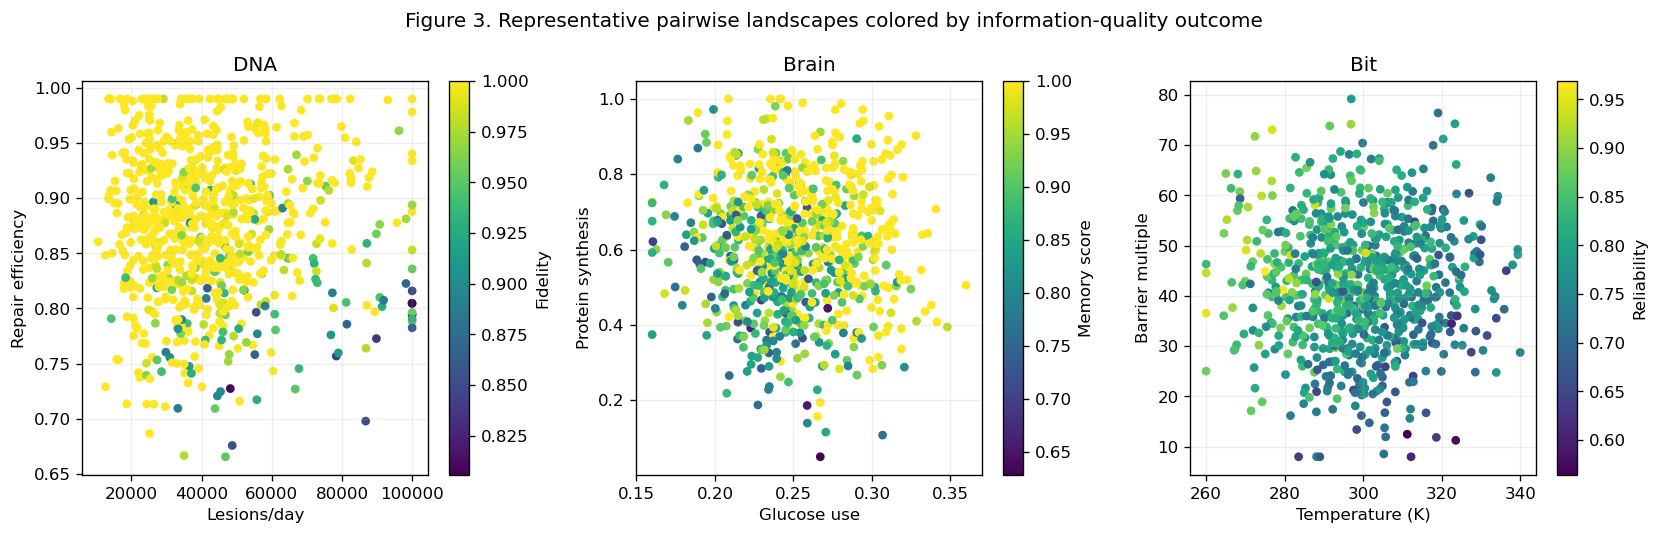

In [13]:

# Figure 3: Domain-specific information landscapes 
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

sc0 = axes[0].scatter(dna['lesions_per_day'], dna['repair_efficiency'],
                      c=dna['dna_information_fidelity'], s=18)
axes[0].set_title('DNA')
axes[0].set_xlabel('Lesions/day')
axes[0].set_ylabel('Repair efficiency')
fig.colorbar(sc0, ax=axes[0], label='Fidelity')

sc1 = axes[1].scatter(brain['brain_glucose_utilization'], brain['protein_synthesis_index'],
                      c=brain['memory_retention_score'], s=18)
axes[1].set_title('Brain')
axes[1].set_xlabel('Glucose use')
axes[1].set_ylabel('Protein synthesis')
fig.colorbar(sc1, ax=axes[1], label='Memory score')

sc2 = axes[2].scatter(bit['temperature_K'], bit['barrier_multiple_landauer'],
                      c=bit['bit_reliability_score'], s=18)
axes[2].set_title('Bit')
axes[2].set_xlabel('Temperature (K)')
axes[2].set_ylabel('Barrier multiple')
fig.colorbar(sc2, ax=axes[2], label='Reliability')

for ax in axes:
    ax.grid(alpha=0.2)

fig.suptitle('Figure 3. Representative pairwise landscapes colored by information-quality outcome')
plt.tight_layout()
fig.savefig(FIG_DIR / 'figure_3_pairwise_landscapes.png', bbox_inches='tight')
plt.show()


,feature,correlation_with_outcome,system
0,repair_efficiency,0.381217,DNA
1,antioxidant_capacity_index,0.154717,DNA
2,chromatin_remodeling_index,0.152694,DNA
3,oxidative_fraction,-0.040597,DNA
4,cell_cycle_pressure_index,-0.103798,DNA
5,replication_stress_index,-0.303658,DNA
6,lesions_per_day,-0.323113,DNA
7,residual_damage_index,-0.786299,DNA
8,synaptic_plasticity_index,0.418431,Brain
9,protein_synthesis_index,0.363676,Brain


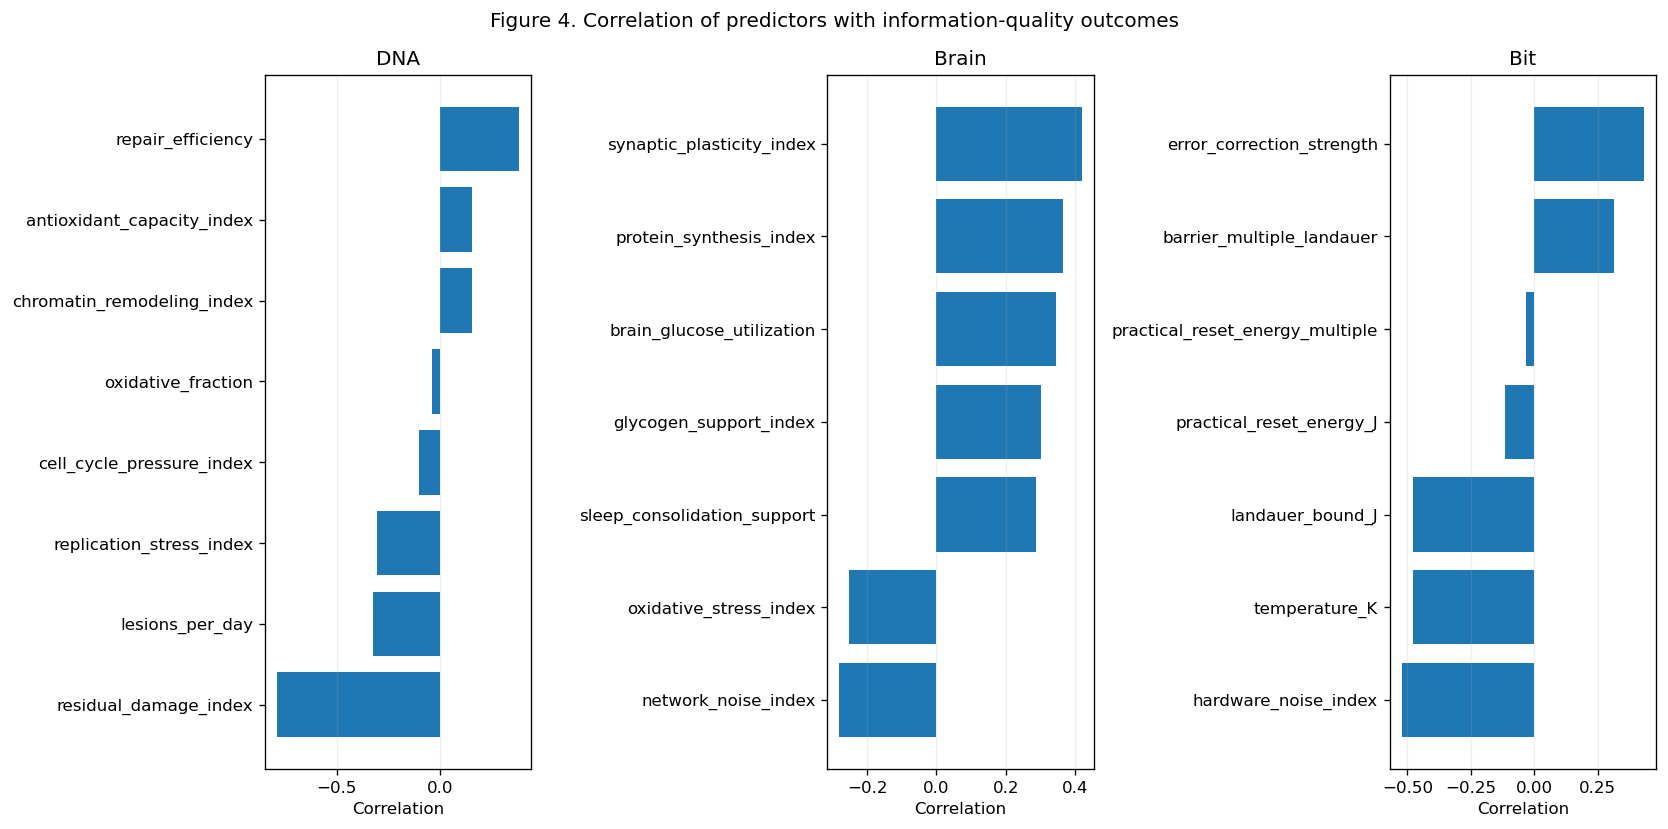

In [15]:

# Correlations 
def outcome_corr(df, outcome, system_name):
    corr = df.corr(numeric_only=True)[outcome].sort_values(ascending=False).drop(outcome)
    return pd.DataFrame({'feature': corr.index, 'correlation_with_outcome': corr.values, 'system': system_name})

corr_dna = outcome_corr(dna.drop(columns=['system']), 'dna_information_fidelity', 'DNA')
corr_brain = outcome_corr(brain.drop(columns=['system']), 'memory_retention_score', 'Brain')
corr_bit = outcome_corr(bit.drop(columns=['system']), 'bit_reliability_score', 'Bit')

corr_all = pd.concat([corr_dna, corr_brain, corr_bit], ignore_index=True)
display(corr_all.head(15))
corr_all.to_csv(TAB_DIR / 'table_4_correlations_with_outcomes.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 7))
for ax, corr_df, title in zip(axes, [corr_dna, corr_brain, corr_bit], ['DNA', 'Brain', 'Bit']):
    y = np.arange(len(corr_df))
    ax.barh(y, corr_df['correlation_with_outcome'])
    ax.set_yticks(y)
    ax.set_yticklabels(corr_df['feature'])
    ax.invert_yaxis()
    ax.set_title(title)
    ax.set_xlabel('Correlation')
    ax.grid(alpha=0.2, axis='x')
fig.suptitle('Figure 4. Correlation of predictors with information-quality outcomes')
plt.tight_layout()
fig.savefig(FIG_DIR / 'figure_4_correlations.png', bbox_inches='tight')
plt.show()


In [17]:

# Supervised learning helpers 
def regression_suite(df, target, system_name):
    X = df.drop(columns=[target, 'system']) if 'system' in df.columns else df.drop(columns=[target])
    y = df[target]
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)

    models = {
        'LinearRegression': LinearRegression(),
        'Ridge': Ridge(alpha=1.0),
        'RandomForest': RandomForestRegressor(n_estimators=250, random_state=SEED),
        'GradientBoosting': GradientBoostingRegressor(random_state=SEED),
        'MLPRegressor': Pipeline([
            ('scale', StandardScaler()),
            ('mlp', MLPRegressor(hidden_layer_sizes=(64, 32), max_iter=1500, random_state=SEED))
        ])
    }

    rows = []
    fitted = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        rows.append({
            'system': system_name,
            'model': name,
            'R2': r2_score(y_test, pred),
            'MAE': mean_absolute_error(y_test, pred),
            'RMSE': mean_squared_error(y_test, pred) ** 0.5
        })
        fitted[name] = (model, X_test, y_test, pred)

    results = pd.DataFrame(rows).sort_values(['R2', 'MAE'], ascending=[False, True])
    return results, fitted

reg_dna, fit_dna = regression_suite(dna, 'dna_information_fidelity', 'DNA')
reg_brain, fit_brain = regression_suite(brain, 'memory_retention_score', 'Brain')
reg_bit, fit_bit = regression_suite(bit, 'bit_reliability_score', 'Bit')

reg_table = pd.concat([reg_dna, reg_brain, reg_bit], ignore_index=True)
display(reg_table)
reg_table.to_csv(TAB_DIR / 'table_5_regression_model_performance.csv', index=False)


,system,model,R2,MAE,RMSE
0,DNA,RandomForest,0.701163,0.006999,0.015257
1,DNA,LinearRegression,0.630532,0.012178,0.016964
2,DNA,GradientBoosting,0.617916,0.007618,0.017251
3,DNA,Ridge,0.509990,0.012762,0.019536
4,DNA,MLPRegressor,-6.571498,0.062098,0.076795
5,Brain,GradientBoosting,0.745689,0.030781,0.039996
6,Brain,LinearRegression,0.733165,0.032039,0.040969
7,Brain,Ridge,0.701804,0.033496,0.043310
8,Brain,RandomForest,0.695328,0.032831,0.043778
9,Brain,MLPRegressor,-0.337624,0.070788,0.091728


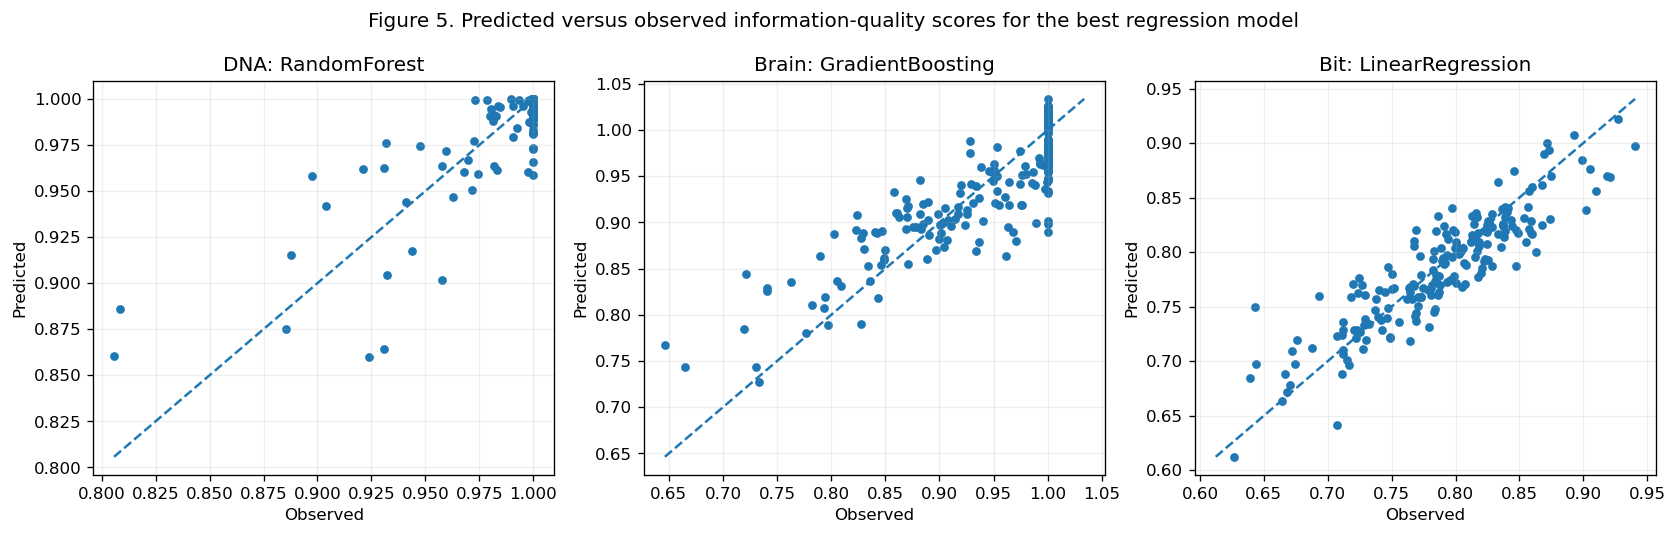

In [19]:

# Figure 5: Best regression predicted vs observed 
best_dna = reg_dna.iloc[0]['model']
best_brain = reg_brain.iloc[0]['model']
best_bit = reg_bit.iloc[0]['model']

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))
for ax, fit_dict, best_name, title in zip(
    axes,
    [fit_dna, fit_brain, fit_bit],
    [best_dna, best_brain, best_bit],
    ['DNA', 'Brain', 'Bit']
):
    model, X_test, y_test, pred = fit_dict[best_name]
    ax.scatter(y_test, pred, s=18)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, linestyle='--')
    ax.set_xlabel('Observed')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{title}: {best_name}')
    ax.grid(alpha=0.2)

fig.suptitle('Figure 5. Predicted versus observed information-quality scores for the best regression model')
plt.tight_layout()
fig.savefig(FIG_DIR / 'figure_5_best_regression_predicted_vs_observed.png', bbox_inches='tight')
plt.show()


In [21]:

# Classification 
def classify_suite(df, target, system_name):
    X = df.drop(columns=[target, 'system']) if 'system' in df.columns else df.drop(columns=[target])
    y_cont = df[target]
    threshold = y_cont.median()
    y = (y_cont >= threshold).astype(int)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED, stratify=y)

    models = {
        'LogisticRegression': Pipeline([('scale', StandardScaler()), ('clf', LogisticRegression(max_iter=2000, random_state=SEED))]),
        'RandomForestClassifier': RandomForestClassifier(n_estimators=250, random_state=SEED),
        'GradientBoostingClassifier': GradientBoostingClassifier(random_state=SEED),
        'MLPClassifier': Pipeline([('scale', StandardScaler()), ('clf', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=1500, random_state=SEED))]),
    }

    rows = []
    fitted = {}
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        if hasattr(model, 'predict_proba'):
            prob = model.predict_proba(X_test)[:, 1]
            auc = roc_auc_score(y_test, prob)
        else:
            auc = np.nan
        pr, rc, f1, _ = precision_recall_fscore_support(y_test, pred, average='binary', zero_division=0)
        rows.append({
            'system': system_name,
            'model': name,
            'accuracy': accuracy_score(y_test, pred),
            'precision': pr,
            'recall': rc,
            'f1': f1,
            'roc_auc': auc
        })
        fitted[name] = (model, X_test, y_test, pred)
    return pd.DataFrame(rows).sort_values(['accuracy', 'f1'], ascending=[False, False]), fitted, threshold

clf_dna, clf_fit_dna, thr_dna = classify_suite(dna, 'dna_information_fidelity', 'DNA')
clf_brain, clf_fit_brain, thr_brain = classify_suite(brain, 'memory_retention_score', 'Brain')
clf_bit, clf_fit_bit, thr_bit = classify_suite(bit, 'bit_reliability_score', 'Bit')

clf_table = pd.concat([clf_dna, clf_brain, clf_bit], ignore_index=True)
display(clf_table)
clf_table.to_csv(TAB_DIR / 'table_6_classification_model_performance.csv', index=False)


,system,model,accuracy,precision,recall,f1,roc_auc
0,DNA,RandomForestClassifier,0.925,0.953333,0.947020,0.950166,0.953169
1,DNA,LogisticRegression,0.915,0.940789,0.947020,0.943894,0.968780
2,DNA,MLPClassifier,0.910,0.934641,0.947020,0.940789,0.907961
3,DNA,GradientBoostingClassifier,0.910,0.940397,0.940397,0.940397,0.963238
4,Brain,LogisticRegression,0.920,0.881818,0.970000,0.923810,0.981900
5,Brain,MLPClassifier,0.910,0.886792,0.940000,0.912621,0.975400
6,Brain,RandomForestClassifier,0.865,0.868687,0.860000,0.864322,0.945800
7,Brain,GradientBoostingClassifier,0.865,0.868687,0.860000,0.864322,0.943900
8,Bit,RandomForestClassifier,0.860,0.852941,0.870000,0.861386,0.943100
9,Bit,GradientBoostingClassifier,0.855,0.838095,0.880000,0.858537,0.941200


In [ ]:

# Feature importance 
def permutation_top_features(df, target, fit_dict, best_model_name, system_name):
    X = df.drop(columns=[target, 'system']) if 'system' in df.columns else df.drop(columns=[target])
    y = df[target]
    _, X_test, _, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
    model = fit_dict[best_model_name][0]
    result = permutation_importance(model, X_test, y_test, n_repeats=10, random_state=SEED)
    imp = pd.DataFrame({
        'feature': X.columns,
        'importance_mean': result.importances_mean,
        'importance_std': result.importances_std,
        'system': system_name
    }).sort_values('importance_mean', ascending=False)
    return imp

imp_dna = permutation_top_features(dna, 'dna_information_fidelity', fit_dna, best_dna, 'DNA')
imp_brain = permutation_top_features(brain, 'memory_retention_score', fit_brain, best_brain, 'Brain')
imp_bit = permutation_top_features(bit, 'bit_reliability_score', fit_bit, best_bit, 'Bit')
imp_table = pd.concat([imp_dna, imp_brain, imp_bit], ignore_index=True)
display(imp_table.groupby('system').head(8))
imp_table.to_csv(TAB_DIR / 'table_7_permutation_importance.csv', index=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
for ax, imp, title in zip(axes, [imp_dna, imp_brain, imp_bit], ['DNA', 'Brain', 'Bit']):
    top = imp.head(8).iloc[::-1]
    ax.barh(top['feature'], top['importance_mean'], xerr=top['importance_std'])
    ax.set_title(title)
    ax.set_xlabel('Permutation importance')
    ax.grid(alpha=0.2, axis='x')

fig.suptitle('Figure 6. Permutation importance for the best regression model in each system')
plt.tight_layout()
fig.savefig(FIG_DIR / 'figure_6_permutation_importance.png', bbox_inches='tight')
plt.show()


In [23]:

# Cross-system harmonization 
dna_h = pd.DataFrame({
    'system': 'DNA',
    'stability_index': 0.45 * dna['repair_efficiency'] + 0.30 * dna['chromatin_remodeling_index'] + 0.25 * dna['antioxidant_capacity_index'],
    'energy_support_index': 0.55 * dna['chromatin_remodeling_index'] + 0.45 * dna['repair_efficiency'],
    'noise_index': 0.50 * (dna['lesions_per_day'] / 1e5) + 0.25 * dna['oxidative_fraction'] + 0.25 * dna['replication_stress_index'],
    'adaptation_index': 0.60 * dna['repair_efficiency'] + 0.40 * dna['chromatin_remodeling_index'],
    'information_score': dna['dna_information_fidelity']
})

brain_h = pd.DataFrame({
    'system': 'Brain',
    'stability_index': 0.40 * brain['protein_synthesis_index'] + 0.35 * brain['synaptic_plasticity_index'] + 0.25 * brain['sleep_consolidation_support'],
    'energy_support_index': 0.60 * brain['brain_glucose_utilization'] / 0.36 + 0.40 * brain['glycogen_support_index'],
    'noise_index': 0.55 * brain['network_noise_index'] + 0.45 * brain['oxidative_stress_index'],
    'adaptation_index': 0.55 * brain['synaptic_plasticity_index'] + 0.45 * brain['protein_synthesis_index'],
    'information_score': brain['memory_retention_score']
})

bit_h = pd.DataFrame({
    'system': 'Bit',
    'stability_index': 0.55 * (bit['barrier_multiple_landauer'] / 90) + 0.45 * bit['error_correction_strength'],
    'energy_support_index': 0.50 * (bit['barrier_multiple_landauer'] / 90) + 0.50 * (bit['practical_reset_energy_multiple'] / 2e6),
    'noise_index': 0.60 * bit['hardware_noise_index'] + 0.40 * np.clip((bit['temperature_K'] - 260) / 80, 0, 1),
    'adaptation_index': bit['error_correction_strength'],
    'information_score': bit['bit_reliability_score']
})

cross = pd.concat([dna_h, brain_h, bit_h], ignore_index=True)
display(cross.head())
cross.to_csv(TAB_DIR / 'table_8_cross_system_dataset.csv', index=False)


,system,stability_index,energy_support_index,noise_index,adaptation_index,information_score
0,DNA,0.716591,0.698469,0.365727,0.746929,1.000000
1,DNA,0.847073,0.853545,0.332598,0.882384,1.000000
2,DNA,0.791785,0.800030,0.464404,0.845981,1.000000
3,DNA,0.751572,0.634666,0.553965,0.674432,0.949354
4,DNA,0.742534,0.655721,0.328549,0.710925,1.000000


,R2,MAE,RMSE
0,0.927175,0.018905,0.02835


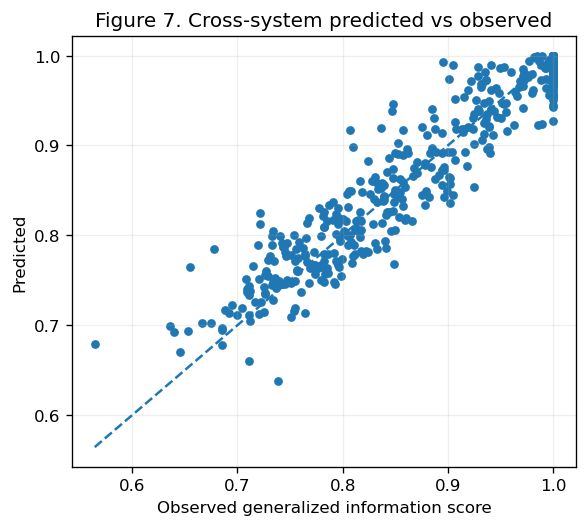

In [25]:

# Cross-system regression 
features = ['stability_index', 'energy_support_index', 'noise_index', 'adaptation_index', 'system']
X = cross[features]
y = cross['information_score']

numeric_features = ['stability_index', 'energy_support_index', 'noise_index', 'adaptation_index']
categorical_features = ['system']

preprocess = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first'), categorical_features)
    ]
)

cross_model = Pipeline([
    ('prep', preprocess),
    ('model', RandomForestRegressor(n_estimators=300, random_state=SEED))
])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=SEED)
cross_model.fit(X_train, y_train)
cross_pred = cross_model.predict(X_test)

cross_metrics = pd.DataFrame([{
    'R2': r2_score(y_test, cross_pred),
    'MAE': mean_absolute_error(y_test, cross_pred),
    'RMSE': mean_squared_error(y_test, cross_pred) ** 0.5
}])
display(cross_metrics)
cross_metrics.to_csv(TAB_DIR / 'table_9_cross_system_regression_metrics.csv', index=False)

fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(y_test, cross_pred, s=18)
lims = [min(y_test.min(), cross_pred.min()), max(y_test.max(), cross_pred.max())]
ax.plot(lims, lims, linestyle='--')
ax.set_xlabel('Observed generalized information score')
ax.set_ylabel('Predicted')
ax.set_title('Figure 7. Cross-system predicted vs observed')
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(FIG_DIR / 'figure_7_cross_system_predicted_vs_observed.png', bbox_inches='tight')
plt.show()


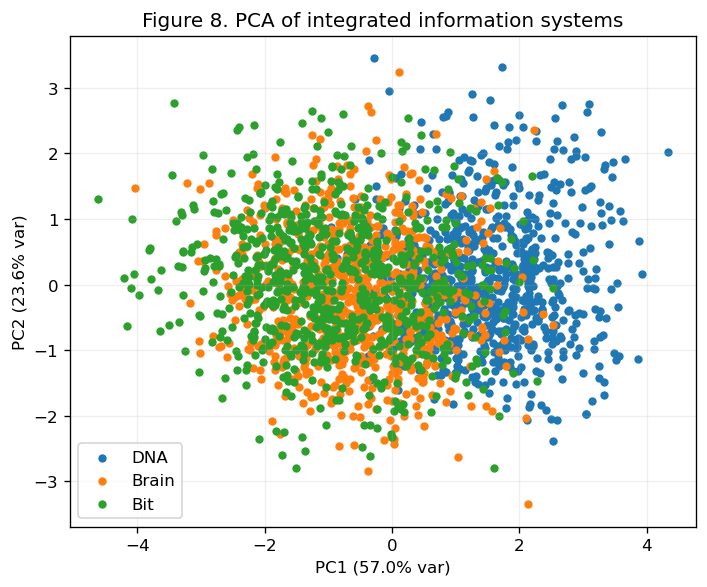

system,Bit,Brain,DNA
cluster,,,
0,51,51,605
1,399,358,21
2,350,391,174


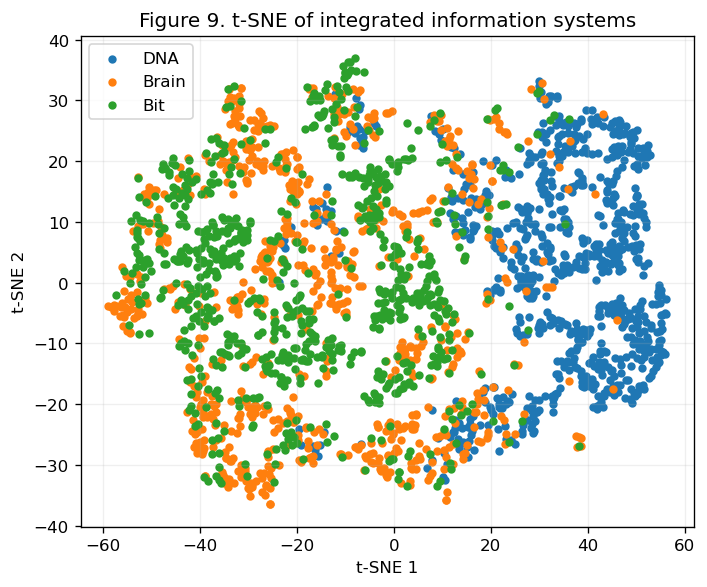

In [27]:

# PCA, KMeans, t-SNE 
X_pca = cross[['stability_index', 'energy_support_index', 'noise_index', 'adaptation_index']].copy()
X_scaled = StandardScaler().fit_transform(X_pca)

pca = PCA(n_components=2, random_state=SEED)
pcs = pca.fit_transform(X_scaled)
cross['PC1'] = pcs[:, 0]
cross['PC2'] = pcs[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
for system_name in ['DNA', 'Brain', 'Bit']:
    sub = cross[cross['system'] == system_name]
    ax.scatter(sub['PC1'], sub['PC2'], s=16, label=system_name)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)')
ax.set_title('Figure 8. PCA of integrated information systems')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(FIG_DIR / 'figure_8_pca.png', bbox_inches='tight')
plt.show()

kmeans = KMeans(n_clusters=3, n_init=20, random_state=SEED)
cross['cluster'] = kmeans.fit_predict(X_scaled)
cluster_table = pd.crosstab(cross['cluster'], cross['system'])
display(cluster_table)
cluster_table.to_csv(TAB_DIR / 'table_10_cluster_composition.csv')

tsne = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto', perplexity=35)
tsne_emb = tsne.fit_transform(X_scaled)
cross['TSNE1'] = tsne_emb[:, 0]
cross['TSNE2'] = tsne_emb[:, 1]

fig, ax = plt.subplots(figsize=(6, 5))
for system_name in ['DNA', 'Brain', 'Bit']:
    sub = cross[cross['system'] == system_name]
    ax.scatter(sub['TSNE1'], sub['TSNE2'], s=16, label=system_name)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('Figure 9. t-SNE of integrated information systems')
ax.legend()
ax.grid(alpha=0.2)
plt.tight_layout()
fig.savefig(FIG_DIR / 'figure_9_tsne.png', bbox_inches='tight')
plt.show()


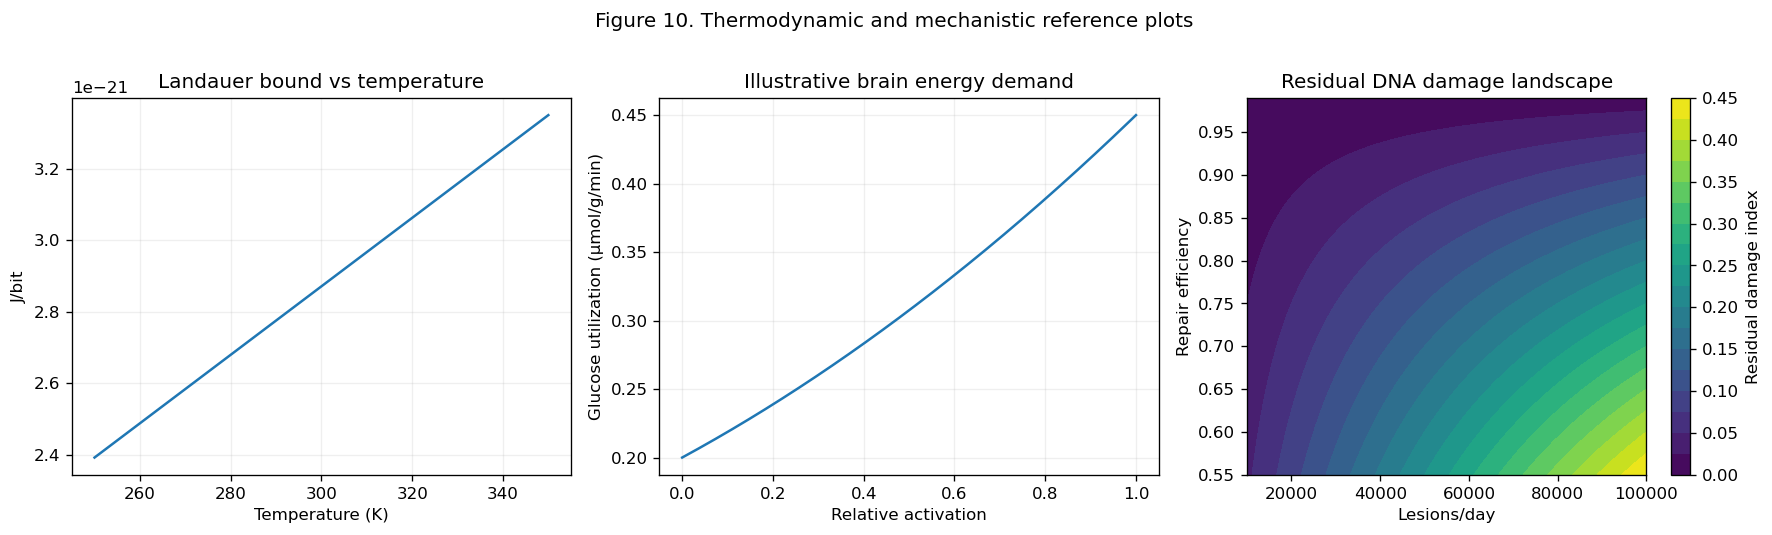

In [29]:

# Thermodynamic reference plots 
# Panel A: Landauer bound vs temperature
temps = np.linspace(250, 350, 300)
landauer_curve = k_B * temps * np.log(2)

# Panel B: illustrative brain energy vs activation
activation = np.linspace(0, 1, 300)
brain_energy = 0.20 + 0.18 * activation + 0.07 * activation**2  # μmol/g/min, illustrative

# Panel C: residual DNA damage contour
lesions_grid = np.linspace(1e4, 1e5, 120)
repair_grid = np.linspace(0.55, 0.99, 120)
L_grid, R_grid = np.meshgrid(lesions_grid, repair_grid)
resid_grid = (L_grid / 1e5) * (1 - R_grid)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(temps, landauer_curve)
axes[0].set_title('Landauer bound vs temperature')
axes[0].set_xlabel('Temperature (K)')
axes[0].set_ylabel('J/bit')
axes[0].grid(alpha=0.2)

axes[1].plot(activation, brain_energy)
axes[1].set_title('Illustrative brain energy demand')
axes[1].set_xlabel('Relative activation')
axes[1].set_ylabel('Glucose utilization (μmol/g/min)')
axes[1].grid(alpha=0.2)

cs = axes[2].contourf(L_grid, R_grid, resid_grid, levels=20)
axes[2].set_title('Residual DNA damage landscape')
axes[2].set_xlabel('Lesions/day')
axes[2].set_ylabel('Repair efficiency')
fig.colorbar(cs, ax=axes[2], label='Residual damage index')

fig.suptitle('Figure 10. Thermodynamic and mechanistic reference plots')
plt.tight_layout()
fig.savefig(FIG_DIR / 'figure_10_thermodynamic_reference_plots.png', bbox_inches='tight')
plt.show()


In [31]:

# Save figure and table manifest 
figure_manifest = pd.DataFrame({
    'filename': sorted([p.name for p in FIG_DIR.glob('figure_*.png')])
})
table_manifest = pd.DataFrame({
    'table_filename': sorted([p.name for p in TAB_DIR.glob('table_*.csv')])
})

display(figure_manifest)
display(table_manifest)

figure_manifest.to_csv(TAB_DIR / 'figure_manifest.csv', index=False)
table_manifest.to_csv(TAB_DIR / 'table_manifest.csv', index=False)


,filename
0,figure_10_thermodynamic_reference_plots.png
1,figure_2_distributions.png
2,figure_3_pairwise_landscapes.png
3,figure_4_correlations.png
4,figure_5_best_regression_predicted_vs_observed...
5,figure_7_cross_system_predicted_vs_observed.png
6,figure_8_pca.png
7,figure_9_tsne.png


,table_filename
0,table_10_cluster_composition.csv
1,table_1_literature_anchors.csv
2,table_2_benchmark_checks.csv
3,table_3_summary_statistics.csv
4,table_4_correlations_with_outcomes.csv
5,table_5_regression_model_performance.csv
6,table_6_classification_model_performance.csv
7,table_8_cross_system_dataset.csv
8,table_9_cross_system_regression_metrics.csv



## Interpretation summary

This notebook demonstrates, using literature-anchored synthetic benchmark data, that:

1. **DNA information fidelity** can be modeled as a balance between lesion burden, repair capacity, chromatin support, and destabilizing stress.
2. **Brain memory retention** can be modeled as a balance between metabolic support, protein synthesis, plasticity, consolidation support, and destabilizing noise.
3. **Bit reliability** can be modeled as a balance between energy barriers, correction strength, temperature, and hardware noise.
4. A **shared comparative model** can learn generalized information quality across all three domains after harmonizing them into common variables such as stability, energy support, noise, and adaptation.

These results are intended as a **proof of concept** and a **reproducible conceptual scaffold**, not as direct empirical claims about real wet-lab, clinical, or hardware datasets.
